# BC MA2025 General

薄入口 notebook：导入 NEURON 与 BrainCell 的 BC cell，配置机制开关，添加刺激与 probe，运行并比较 soma 和全 compartment 电压。

In [1]:
from pathlib import Path
import sys
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import brainunit as u
from neuron import h

def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.neuron_compare.cell.bc_ma2025.debug.bc_parameters import (
    DEFAULT_MORPH_PATH,
    DEFAULT_NRNMECH_PATH,
    BCConfig,
    BCToggles,
    load_bc25_params,
    toggle_names,
)
from examples.neuron_compare.cell.bc_ma2025.debug.bc_neuron_debug import BC as NeuronBC
from examples.neuron_compare.cell.bc_ma2025.debug.bc_braincell_debug import BC as BrainCellBC

import braincell
from braincell import mech
from braincell.filter import at
print("braincell import:", braincell.__file__)
import brainstate
brainstate.environ.set(precision=64)

--No graphics will be displayed.


braincell import: /home/swl/braincell-ion_dyn/braincell/__init__.py


In [2]:
params = load_bc25_params()

# Presets: "all", "leak_only", "manual".
# Use "manual" when you want direct control of every channel/ion below.
toggle_mode = "all"

# Passive current.
leak =  True
# Sodium channels.
nav1p1 =  True
nav1p6 =  True

# Calcium channels.
cav1p2 =   True
cav1p3 =   True
cav2p1 =   True
cav3p2 =   True

# Potassium channels.
kir2p3 =  True
kv1p1 = True
kv3p4 = True
kv4p3 = True

# Calcium-activated potassium channels.
kca1p1 =   True
kca2p2 =  True
kca3p1 =  True

# HCN channel.
hcn1 =  True

# Calcium ion/pool. When False, calcium-dependent/channel tests use CalciumFixed if needed.
cdp =  True
manual_toggles = {
    "leak": leak,
    "nav1p1": nav1p1,
    "nav1p6": nav1p6,
    "cav1p2": cav1p2,
    "cav1p3": cav1p3,
    "cav2p1": cav2p1,
    "cav3p2": cav3p2,
    "kir2p3": kir2p3,
    "kv1p1": kv1p1,
    "kv3p4": kv3p4,
    "kv4p3": kv4p3,
    "kca1p1": kca1p1,
    "kca2p2": kca2p2,
    "kca3p1": kca3p1,
    "hcn1": hcn1,
    "cdp": cdp,
}

def make_toggles(mode="all", **overrides):
    names = toggle_names()
    if mode == "all":
        values = {name: True for name in names}
    elif mode == "leak_only":
        values = {name: False for name in names}
        values["leak"] = True
    elif mode == "manual":
        values = {name: bool(manual_toggles.get(name, False)) for name in names}
    else:
        raise ValueError(f"Unknown toggle_mode {mode!r}.")
    values.update({key: bool(value) for key, value in overrides.items()})
    return BCToggles(**values)

toggles = make_toggles(toggle_mode)
config = BCConfig(toggles=toggles, temperature_celsius=36.0, v_init_mV=-65.0)

dt_ms = 0.05
duration_ms = 50.0
delay_ms = 10.0
stim_dur_ms = 80.0
amp_nA = 0.05

# Cav2.1 GHK-current debug. This freezes only GHK current-drive voltage, not gates.
use_frozen_cav2p1 = True

display(pd.DataFrame(
    [
        {"group": "passive", "name": "leak", "enabled": toggles.leak},
        {"group": "sodium", "name": "nav1p1", "enabled": toggles.nav1p1},
        {"group": "sodium", "name": "nav1p6", "enabled": toggles.nav1p6},
        {"group": "calcium_channel", "name": "cav1p2", "enabled": toggles.cav1p2},
        {"group": "calcium_channel", "name": "cav1p3", "enabled": toggles.cav1p3},
        {"group": "calcium_channel", "name": "cav2p1", "enabled": toggles.cav2p1},
        {"group": "calcium_channel", "name": "cav3p2", "enabled": toggles.cav3p2},
        {"group": "potassium", "name": "kir2p3", "enabled": toggles.kir2p3},
        {"group": "potassium", "name": "kv1p1", "enabled": toggles.kv1p1},
        {"group": "potassium", "name": "kv3p4", "enabled": toggles.kv3p4},
        {"group": "potassium", "name": "kv4p3", "enabled": toggles.kv4p3},
        {"group": "kca", "name": "kca1p1", "enabled": toggles.kca1p1},
        {"group": "kca", "name": "kca2p2", "enabled": toggles.kca2p2},
        {"group": "kca", "name": "kca3p1", "enabled": toggles.kca3p1},
        {"group": "hcn", "name": "hcn1", "enabled": toggles.hcn1},
        {"group": "ion", "name": "cdp", "enabled": toggles.cdp},
    ]
))
params.to_dict()

,group,name,enabled
0,passive,leak,True
1,sodium,nav1p1,True
2,sodium,nav1p6,True
3,calcium_channel,cav1p2,True
4,calcium_channel,cav1p3,True
5,calcium_channel,cav2p1,True
6,calcium_channel,cav3p2,True
7,potassium,kir2p3,True
8,potassium,kv1p1,True
9,potassium,kv3p4,True


{'soma': {'leak': 4e-05,
  'nav1p1': 0.2,
  'nav1p6': 0.0,
  'cav1p2': 0.0007,
  'cav1p3': 5e-06,
  'cav2p1': 0.0,
  'cav3p2': 0.0001,
  'kir2p3': 0.0001,
  'kv1p1': 0.0,
  'kv3p4': 0.097,
  'kv4p3': 0.01,
  'kca1p1': 0.0,
  'kca2p2': 0.0,
  'kca3p1': 0.001,
  'hcn1': 0.001,
  'cdp_pump': 2e-09},
 'dend': {'leak': 1e-05,
  'nav1p1': 0.0,
  'nav1p6': 0.0,
  'cav1p2': 0.0002,
  'cav1p3': 5e-06,
  'cav2p1': 0.0,
  'cav3p2': 5e-05,
  'kir2p3': 0.0,
  'kv1p1': 0.0,
  'kv3p4': 0.0,
  'kv4p3': 0.00987201764943,
  'kca1p1': 0.0,
  'kca2p2': 0.0065,
  'kca3p1': 0.0,
  'hcn1': 0.0,
  'cdp_pump': 2e-09},
 'axon_ais': {'leak': 1e-05,
  'nav1p1': 0.0,
  'nav1p6': 0.3,
  'cav1p2': 0.0,
  'cav1p3': 0.0,
  'cav2p1': 0.00022,
  'cav3p2': 0.0,
  'kir2p3': 0.0,
  'kv1p1': 0.0,
  'kv3p4': 0.002,
  'kv4p3': 0.0,
  'kca1p1': 0.01,
  'kca2p2': 0.0,
  'kca3p1': 0.0,
  'hcn1': 0.001,
  'cdp_pump': 2e-09},
 'axon_regular': {'leak': 1e-06,
  'nav1p1': 0.0,
  'nav1p6': 0.001,
  'cav1p2': 0.0,
  'cav1p3': 0.0,
  '

In [3]:
neuron_bc = NeuronBC(
    DEFAULT_MORPH_PATH,
    params=params,
    config=config,
    nrnmech_path=DEFAULT_NRNMECH_PATH,
).build()
braincell_bc = BrainCellBC(
    DEFAULT_MORPH_PATH,
    params=params,
    config=config,
    frozen=use_frozen_cav2p1,
).build()

display(pd.Series(neuron_bc.summary(), dtype=object))
display(pd.Series(braincell_bc.summary(), dtype=object))
display(neuron_bc.branch_table().head())
display(braincell_bc.branch_table().head())
display(neuron_bc.branch_table()["source_region"].value_counts().sort_index())
display(braincell_bc.branch_table()["source_region"].value_counts().sort_index())


6633 lines read

/home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/BC/morphology/BC.asc problems


Main branch starting at line 168 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 3401 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 4942 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 5437 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 6075 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 6282 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 6332 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma


/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [124]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [107]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [17]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(


backend                                                          neuron
morph_path            /home/swl/braincell-ion_dyn/examples/neuron_co...
toggles               {'leak': True, 'nav1p1': True, 'nav1p6': True,...
branch_counts         {'n_soma': 1, 'n_dend': 42, 'n_axon': 71, 'n_t...
region_counts         {'axon_ais': 1, 'axon_regular': 70, 'dend': 42...
compartment_counts                                {'n_total_nseg': 152}
enabled_mechanisms    {'soma': ['leak', 'nav1p1', 'cav3p2', 'cav1p2'...
dtype: object

backend                                                       braincell
morph_path            /home/swl/braincell-ion_dyn/examples/neuron_co...
toggles               {'leak': True, 'nav1p1': True, 'nav1p6': True,...
frozen                                                             True
branch_counts         {'n_soma': 1, 'n_dend': 42, 'n_axon': 71, 'n_t...
region_counts         {'axon_ais': 1, 'axon_regular': 70, 'dend': 42...
compartment_counts                                  {'n_total_cv': 152}
enabled_mechanisms    {'soma': ['leak', 'nav1p1', 'cav3p2', 'cav1p2'...
dtype: object

,branch_index,branch_name,branch_type,source_region,source_local_index,diam_um,diam_arc_mean_um,cm_uF_cm2,nseg,has_cav1p2,...,has_kca2p2,has_kca3p1,has_kir2p3,has_kv1p1,has_kv3p4,has_kv4p3,has_leak,has_nav1p1,has_nav1p6,enabled_mechanisms
0,0,soma[0],soma,soma,0,4.666598,4.666598,1.0,1,True,...,False,True,True,False,True,True,True,True,False,"[cav1p2, cav1p3, cav3p2, cdp, hcn1, kca3p1, ki..."
1,1,axon[0],axon,axon_ais,0,0.421807,0.421807,1.0,1,False,...,False,False,False,False,True,False,True,False,True,"[cav2p1, cdp, hcn1, kca1p1, kv3p4, leak, nav1p6]"
2,2,axon[1],axon,axon_regular,1,0.594423,0.594423,1.0,1,False,...,False,False,False,True,True,False,True,False,True,"[cav2p1, cdp, hcn1, kca1p1, kv1p1, kv3p4, leak..."
3,3,axon[2],axon,axon_regular,2,0.624262,0.624262,1.0,1,False,...,False,False,False,True,True,False,True,False,True,"[cav2p1, cdp, hcn1, kca1p1, kv1p1, kv3p4, leak..."
4,4,axon[3],axon,axon_regular,3,0.601274,0.601274,1.0,1,False,...,False,False,False,True,True,False,True,False,True,"[cav2p1, cdp, hcn1, kca1p1, kv1p1, kv3p4, leak..."


,branch_index,branch_name,branch_type,source_region,source_local_index,diam_arc_mean_um,cm_uF_cm2,n_cv,has_cav1p2,has_cav1p3,...,has_kca2p2,has_kca3p1,has_kir2p3,has_kv1p1,has_kv3p4,has_kv4p3,has_leak,has_nav1p1,has_nav1p6,enabled_mechanisms
0,0,soma,soma,soma,0,4.666595,1.0,1,True,True,...,False,True,True,False,True,True,True,True,False,"[cav1p2, cav1p3, cav3p2, cdp, hcn1, kca3p1, ki..."
1,1,axon_0,axon,axon_ais,0,0.421807,1.0,1,False,False,...,False,False,False,False,True,False,True,False,True,"[cav2p1, cdp, hcn1, kca1p1, kv3p4, leak, nav1p6]"
2,2,axon_1,axon,axon_regular,1,0.594423,1.0,1,False,False,...,False,False,False,True,True,False,True,False,True,"[cav2p1, cdp, hcn1, kca1p1, kv1p1, kv3p4, leak..."
3,3,axon_2,axon,axon_regular,2,0.624262,1.0,1,False,False,...,False,False,False,True,True,False,True,False,True,"[cav2p1, cdp, hcn1, kca1p1, kv1p1, kv3p4, leak..."
4,4,axon_3,axon,axon_regular,3,0.601274,1.0,1,False,False,...,False,False,False,True,True,False,True,False,True,"[cav2p1, cdp, hcn1, kca1p1, kv1p1, kv3p4, leak..."


source_region
axon_ais         1
axon_regular    70
dend            42
soma             1
Name: count, dtype: int64

source_region
axon_ais         1
axon_regular    70
dend            42
soma             1
Name: count, dtype: int64

In [4]:
nrn_voltage_probes = neuron_bc.attach_voltage_probes(all_compartments=True, soma=True)
bc_voltage_probes = braincell_bc.attach_voltage_probes(all_compartments=True, soma=True)

In [5]:
stim = h.IClamp(neuron_bc.root_soma(0.5))
stim.delay = delay_ms
stim.dur = stim_dur_ms
stim.amp = amp_nA
h.cvode_active(0)
h.dt = dt_ms
h.steps_per_ms = 1.0 / h.dt
h.celsius = config.temperature_celsius
h.tstop = duration_ms
h.v_init = config.v_init_mV
t_neuron = h.Vector().record(h._ref_t)
h.finitialize(h.v_init)
h.run()

braincell_bc.cell.place(
    at("soma", 0.5),
    mech.CurrentClamp.step(amp_nA * u.nA, stim_dur_ms * u.ms, delay=delay_ms * u.ms),
)
braincell_bc.cell.init_state()
braincell_bc.cell.reset_state()
bc_run = braincell_bc.cell.run(dt=dt_ms * u.ms, duration=duration_ms * u.ms)

In [6]:
nrn_v = neuron_bc.collect_voltage_results(nrn_voltage_probes)
bc_v = braincell_bc.collect_voltage_results(bc_voltage_probes, bc_run)

reference_time_ms = np.round(np.arange(0.0, duration_ms, dt_ms, dtype=float), decimals=12)
neuron_time_raw = np.asarray(t_neuron, dtype=float).reshape(-1)

def trim_neuron_trace(values, reference_time_ms):
    values = np.asarray(values, dtype=float).reshape(-1)
    if values.shape[0] == reference_time_ms.shape[0] + 1:
        return values[1:]
    return values

neuron_soma = trim_neuron_trace(nrn_v["soma_voltage_mV"], reference_time_ms)
if nrn_v["compartment_voltage_mV"].shape[0] == reference_time_ms.shape[0] + 1:
    neuron_comp = nrn_v["compartment_voltage_mV"][1:, :]
else:
    neuron_comp = nrn_v["compartment_voltage_mV"]
braincell_soma = bc_v["soma_voltage_mV"]
braincell_comp = bc_v["compartment_voltage_mV"]

def metric_dict(a, b):
    delta = np.asarray(b) - np.asarray(a)
    return {
        "rmse": float(np.sqrt(np.mean(delta ** 2))),
        "max_abs": float(np.max(np.abs(delta))),
        "mean_abs": float(np.mean(np.abs(delta))),
    }

delta_soma = braincell_soma - neuron_soma
soma_summary = {
    "voltage_rmse_mV": float(np.sqrt(np.mean(delta_soma ** 2))),
    "voltage_max_abs_mV": float(np.max(np.abs(delta_soma))),
    "voltage_mean_abs_mV": float(np.mean(np.abs(delta_soma))),
}

display({
    "neuron_time_points": int(neuron_time_raw.shape[0]),
    "reference_time_points": int(reference_time_ms.shape[0]),
    "braincell_soma_points": int(braincell_soma.shape[0]),
    "neuron_soma_points": int(neuron_soma.shape[0]),
})
soma_summary

{'neuron_time_points': 1001,
 'reference_time_points': 1000,
 'braincell_soma_points': 1000,
 'neuron_soma_points': 1000}

{'voltage_rmse_mV': 0.0006567968617150646,
 'voltage_max_abs_mV': 0.010245849001446317,
 'voltage_mean_abs_mV': 0.0001482587769090733}

In [7]:
pair_table = pd.merge(
    bc_v["compartment_table"],
    nrn_v["compartment_table"],
    on=["source_region", "source_local_index", "local_index"],
    suffixes=("_braincell", "_neuron"),
)
metric_rows = []
for row in pair_table.itertuples(index=False):
    bc_idx = int(row.compartment_index_braincell)
    nrn_idx = int(row.compartment_index_neuron)
    delta = braincell_comp[:, bc_idx] - neuron_comp[:, nrn_idx]
    metric_rows.append(
        {
            "source_region": row.source_region,
            "source_local_index": int(row.source_local_index),
            "local_index": int(row.local_index),
            "branch_name_braincell": row.branch_name_braincell,
            "branch_name_neuron": row.branch_name_neuron,
            "mean_abs_mV": float(np.mean(np.abs(delta))),
            "rmse_mV": float(np.sqrt(np.mean(delta ** 2))),
            "max_abs_mV": float(np.max(np.abs(delta))),
        }
    )
compartment_metrics = pd.DataFrame(metric_rows)
display(compartment_metrics.sort_values("max_abs_mV", ascending=False).head(20))
display(
    {
        "paired_compartments": int(len(compartment_metrics)),
        "mean_of_mean_abs_mV": float(compartment_metrics["mean_abs_mV"].mean()),
        "mean_of_rmse_mV": float(compartment_metrics["rmse_mV"].mean()),
        "max_abs_mV": float(compartment_metrics["max_abs_mV"].max()),
    }
)

,source_region,source_local_index,local_index,branch_name_braincell,branch_name_neuron,mean_abs_mV,rmse_mV,max_abs_mV
1,axon_ais,0,0,axon_0,axon[0],0.000206,0.001104,0.026328
0,soma,0,0,soma,soma[0],0.000148,0.000657,0.010246
86,dend,0,0,dendrite_0,dend[0],0.000145,0.000637,0.009851
124,dend,20,0,dendrite_20,dend[20],0.000142,0.000616,0.009576
115,dend,15,0,dendrite_15,dend[15],0.000139,0.000597,0.009353
145,dend,39,0,dendrite_39,dend[39],0.000139,0.000599,0.009345
144,dend,38,0,dendrite_38,dend[38],0.000141,0.000596,0.009181
140,dend,36,0,dendrite_36,dend[36],0.000135,0.000566,0.008905
87,dend,1,0,dendrite_1,dend[1],0.000128,0.000544,0.008571
125,dend,21,0,dendrite_21,dend[21],0.000129,0.000528,0.008313


{'paired_compartments': 152,
 'mean_of_mean_abs_mV': 6.446102276437812e-05,
 'mean_of_rmse_mV': 0.00020108252142812997,
 'max_abs_mV': 0.026328004008101757}

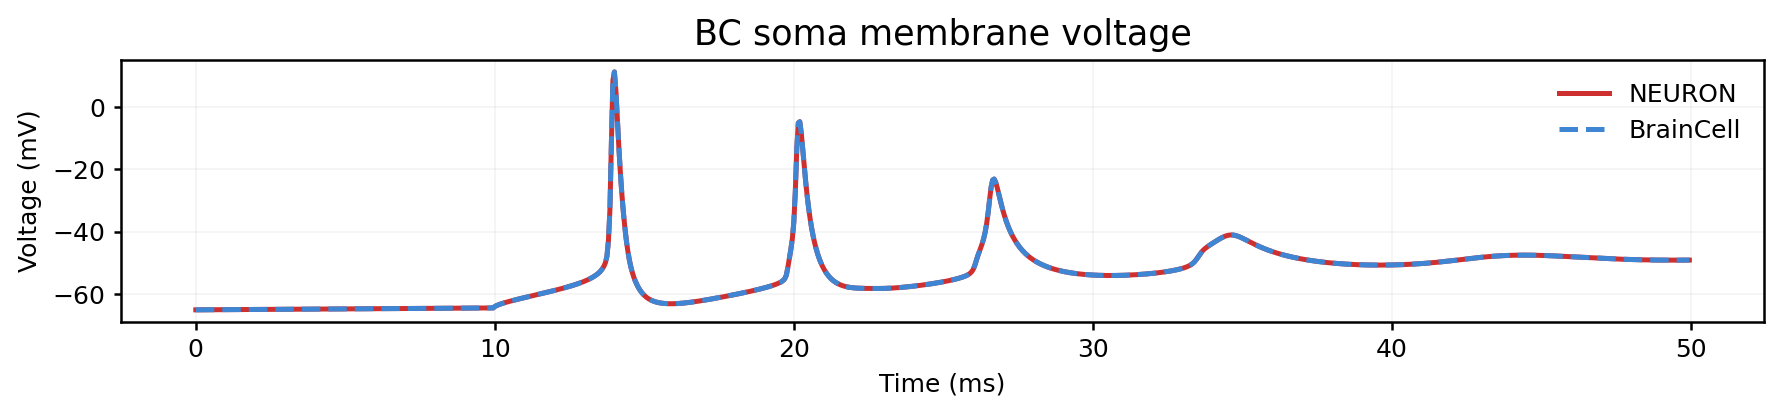

In [8]:
figure_style = {
    "fig_width": 10,
    "panel_height": 2.4,
    "dpi": 180,
    "font_family": "DejaVu Sans",
    "title_size": 14,
    "axis_label_size": 10,
    "tick_label_size": 10,
    "legend_size": 10,
    "line_width": 2,
    "spine_width": 1,
    "tick_width": 1,
    "tick_length": 3.0,
    "grid_alpha": 0.16,
    "neuron_color": "#CE2F2F",
    "braincell_color": "#3E86D4",
    "save_path": None,
}

with plt.rc_context(
    {
        "font.family": figure_style["font_family"],
        "font.size": figure_style["tick_label_size"],
        "axes.linewidth": figure_style["spine_width"],
        "axes.labelsize": figure_style["axis_label_size"],
        "axes.titlesize": figure_style["title_size"],
        "xtick.labelsize": figure_style["tick_label_size"],
        "ytick.labelsize": figure_style["tick_label_size"],
        "legend.fontsize": figure_style["legend_size"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
):
    fig, ax = plt.subplots(
        1,
        1,
        figsize=(figure_style["fig_width"], figure_style["panel_height"]),
        dpi=figure_style["dpi"],
    )
    n = min(len(reference_time_ms), len(neuron_soma), len(braincell_soma))
    ax.plot(reference_time_ms[:n], neuron_soma[:n], color=figure_style["neuron_color"], lw=figure_style["line_width"], label="NEURON")
    ax.plot(reference_time_ms[:n], braincell_soma[:n], color=figure_style["braincell_color"], lw=figure_style["line_width"], ls="--", label="BrainCell")
    ax.set_title("BC soma membrane voltage")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Voltage (mV)")
    ax.grid(alpha=figure_style["grid_alpha"], linewidth=0.6)
    ax.tick_params(width=figure_style["tick_width"], length=figure_style["tick_length"])
    ax.legend(frameon=False, loc="best")
    fig.tight_layout()
    if figure_style["save_path"]:
        fig.savefig(figure_style["save_path"], bbox_inches="tight")
    plt.show()

In [9]:
# Optional cleanup when re-running cells in the same kernel.
# neuron_bc.cleanup()